# Taller 05 — Reconocimiento de vocales con red neuronal

**Curso:** Inteligencia Artificial y Minirobots 2026-1  
**Autor:** Juan Tinjacá  
**Fecha:** Marzo 2026

---

## 1. Objetivo

Entrenar una red neuronal artificial implementada desde cero para clasificar las cinco vocales del español (A, E, I, O, U) representadas como matrices de píxeles de 4×5, evaluando su capacidad de generalización ante versiones con ruido.

## 2. Supuestos

- Cada vocal se representa como una matriz binaria de **4 columnas × 5 filas** (20 píxeles), aplanada en un vector de 20 valores en {0, 1}.
- La red neuronal tiene arquitectura **20 → 8 → 5**: capa de entrada (20), una capa oculta (8 neuronas, activación sigmoide) y capa de salida (5 neuronas, activación sigmoide con codificación one-hot).
- El entrenamiento usa **retropropagación con descenso de gradiente** implementado manualmente en NumPy, sin librerías de ML.
- La función de pérdida es el **Error Cuadrático Medio (MSE)**.
- Se generan versiones con ruido de cada vocal para evaluar robustez (flip aleatorio de píxeles con p=0.1).
- La implementación prioriza claridad pedagógica sobre eficiencia computacional.

## 3. Desarrollo

### Instalación de dependencias

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "numpy", "-q"])
print("Dependencias listas.")

Dependencias listas.


### 3.1 Codificación de vocales como matrices 4×5

In [2]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Vocales codificadas como matrices 5 filas x 4 columnas (binario)
# 1 = píxel encendido, 0 = apagado
VOCALES_RAW = {
    "A": [[0,1,1,0],
          [1,0,0,1],
          [1,1,1,1],
          [1,0,0,1],
          [1,0,0,1]],

    "E": [[1,1,1,1],
          [1,0,0,0],
          [1,1,1,0],
          [1,0,0,0],
          [1,1,1,1]],

    "I": [[1,1,1,1],
          [0,1,1,0],
          [0,1,1,0],
          [0,1,1,0],
          [1,1,1,1]],

    "O": [[0,1,1,0],
          [1,0,0,1],
          [1,0,0,1],
          [1,0,0,1],
          [0,1,1,0]],

    "U": [[1,0,0,1],
          [1,0,0,1],
          [1,0,0,1],
          [1,0,0,1],
          [0,1,1,0]],
}

ETIQUETAS = ["A", "E", "I", "O", "U"]

# Vectores de entrada (aplanados) y salidas one-hot
X = np.array([np.array(VOCALES_RAW[v]).flatten() for v in ETIQUETAS], dtype=float)
Y = np.eye(5)  # one-hot: A=[1,0,0,0,0], E=[0,1,0,0,0], ...

print(f"X shape: {X.shape}  (5 vocales × 20 píxeles)")
print(f"Y shape: {Y.shape}  (5 vocales × 5 clases)")

X shape: (5, 20)  (5 vocales × 20 píxeles)
Y shape: (5, 5)  (5 vocales × 5 clases)


### 3.2 Visualización de las vocales

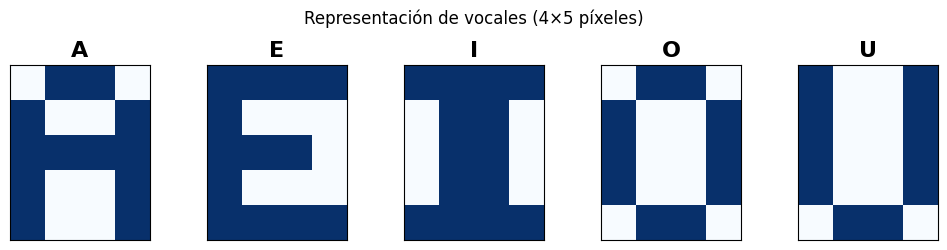

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
for ax, vocal in zip(axes, ETIQUETAS):
    matriz = np.array(VOCALES_RAW[vocal])
    ax.imshow(matriz, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(vocal, fontsize=16, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Representación de vocales (4×5 píxeles)", fontsize=12)
plt.tight_layout()
plt.savefig("vocales.png", dpi=120, bbox_inches="tight")
plt.show()

### 3.3 Red neuronal desde cero

Arquitectura: **20 entradas → 8 neuronas ocultas → 5 salidas**

- Activación: sigmoide σ(z) = 1 / (1 + e^−z)
- Pérdida: MSE = (1/n) Σ (ŷ − y)²
- Actualización: W ← W − α · ∂L/∂W  (descenso de gradiente)

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(a):
    """Derivada de sigmoid expresada en términos de la activación a."""
    return a * (1 - a)


class RedNeuronal:
    """
    Red neuronal de una capa oculta.
    Arquitectura: entrada_dim → oculta_dim → salida_dim
    """
    def __init__(self, entrada_dim, oculta_dim, salida_dim, lr=0.5, seed=SEED):
        np.random.seed(seed)
        # Pesos inicializados con distribución normal escalada
        self.W1 = np.random.randn(entrada_dim, oculta_dim) * 0.5
        self.b1 = np.zeros((1, oculta_dim))
        self.W2 = np.random.randn(oculta_dim, salida_dim) * 0.5
        self.b2 = np.zeros((1, salida_dim))
        self.lr = lr

    def forward(self, X):
        """Propagación hacia adelante."""
        self.z1 = X @ self.W1 + self.b1
        self.a1 = sigmoid(self.z1)          # activación capa oculta
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = sigmoid(self.z2)          # activación capa salida
        return self.a2

    def backward(self, X, Y):
        """Retropropagación y actualización de pesos."""
        n = X.shape[0]

        # Gradiente capa de salida
        delta2 = (self.a2 - Y) * sigmoid_deriv(self.a2)   # (n, 5)
        dW2    = self.a1.T @ delta2 / n
        db2    = delta2.mean(axis=0, keepdims=True)

        # Gradiente capa oculta
        delta1 = (delta2 @ self.W2.T) * sigmoid_deriv(self.a1)  # (n, 8)
        dW1    = X.T @ delta1 / n
        db1    = delta1.mean(axis=0, keepdims=True)

        # Actualización
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def perdida(self, X, Y):
        pred = self.forward(X)
        return np.mean((pred - Y) ** 2)

    def predecir(self, x):
        salida = self.forward(x.reshape(1, -1))
        return ETIQUETAS[np.argmax(salida)], salida.flatten()

## 4. Ejecución — Entrenamiento

In [5]:
EPOCAS = 5000
LR     = 0.8

red = RedNeuronal(entrada_dim=20, oculta_dim=8, salida_dim=5, lr=LR)
historial_perdida = []

for epoca in range(EPOCAS):
    red.forward(X)
    red.backward(X, Y)
    if epoca % 100 == 0:
        loss = red.perdida(X, Y)
        historial_perdida.append((epoca, loss))

loss_final = red.perdida(X, Y)
print(f"Entrenamiento completado — Pérdida final (MSE): {loss_final:.6f}")

Entrenamiento completado — Pérdida final (MSE): 0.000271


## 5. Resultado

### 5.1 Curva de pérdida

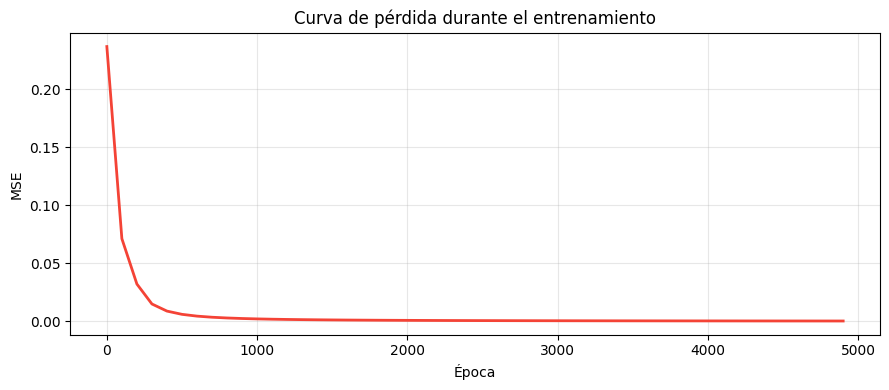

In [6]:
epocas_log, losses_log = zip(*historial_perdida)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epocas_log, losses_log, color="#F44336", linewidth=2)
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.set_title("Curva de pérdida durante el entrenamiento")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("curva_perdida.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Clasificación de los ejemplos de entrenamiento

In [7]:
print(f"{'Vocal':>6} | {'Predicción':>10} | {'Correcto':>8} | Activaciones de salida")
print("-" * 70)
for i, vocal in enumerate(ETIQUETAS):
    pred, activaciones = red.predecir(X[i])
    correcto = "✓" if pred == vocal else "✗"
    act_str  = "  ".join([f"{ETIQUETAS[j]}:{activaciones[j]:.3f}" for j in range(5)])
    print(f"{vocal:>6} | {pred:>10} | {correcto:>8} | {act_str}")

 Vocal | Predicción | Correcto | Activaciones de salida
----------------------------------------------------------------------
     A |          A |        ✓ | A:0.978  E:0.015  I:0.015  O:0.015  U:0.007
     E |          E |        ✓ | A:0.012  E:0.975  I:0.018  O:0.005  U:0.012
     I |          I |        ✓ | A:0.011  E:0.011  I:0.975  O:0.004  U:0.010
     O |          O |        ✓ | A:0.021  E:0.013  I:0.001  O:0.973  U:0.022
     U |          U |        ✓ | A:0.001  E:0.018  I:0.018  O:0.020  U:0.977


### 5.3 Prueba con vocales con ruido (generalización)


 Vocal | Predicción | Correcto
-----------------------------------
     A |          A |        ✓
     E |          E |        ✓
     I |          I |        ✓
     O |          O |        ✓
     U |          U |        ✓


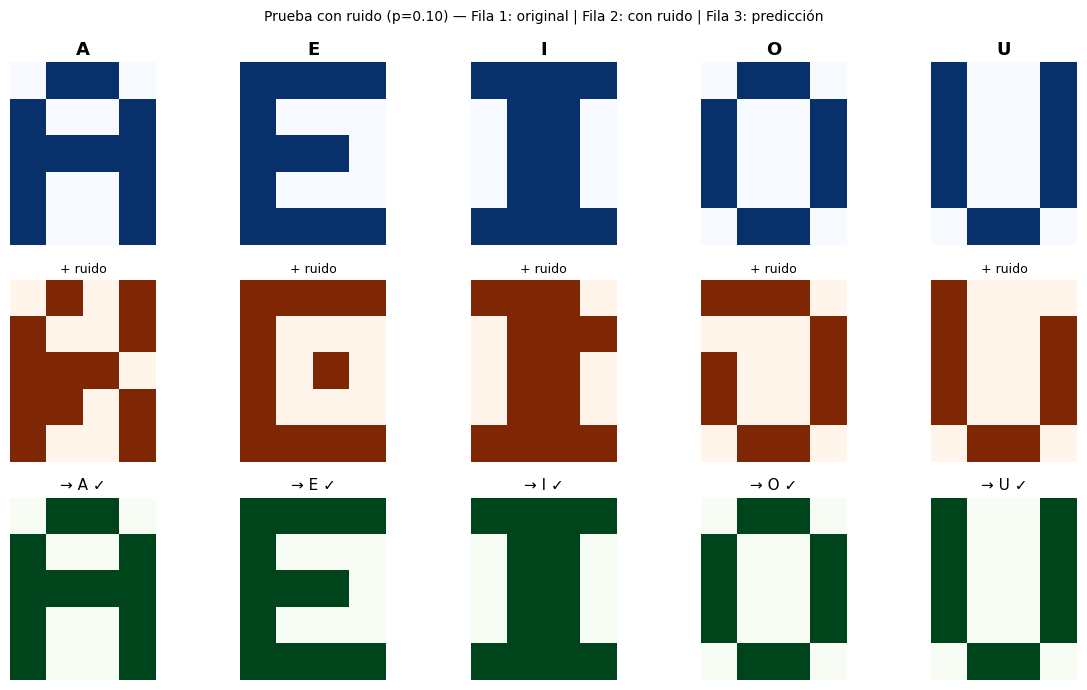

In [8]:
def agregar_ruido(vector, p_ruido=0.10, seed=None):
    """Invierte píxeles aleatoriamente con probabilidad p_ruido."""
    rng = np.random.default_rng(seed)
    ruidoso = vector.copy()
    mascara = rng.random(len(vector)) < p_ruido
    ruidoso[mascara] = 1 - ruidoso[mascara]
    return ruidoso

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
fig.suptitle("Prueba con ruido (p=0.10) — Fila 1: original | Fila 2: con ruido | Fila 3: predicción",
             fontsize=10)

print(f"\n{'Vocal':>6} | {'Predicción':>10} | {'Correcto':>8}")
print("-" * 35)

for j, vocal in enumerate(ETIQUETAS):
    original = X[j]
    ruidoso  = agregar_ruido(original, p_ruido=0.10, seed=j)
    pred, _  = red.predecir(ruidoso)
    correcto = "✓" if pred == vocal else "✗"
    print(f"{vocal:>6} | {pred:>10} | {correcto:>8}")

    # Fila 1: original
    axes[0, j].imshow(original.reshape(5, 4), cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    axes[0, j].set_title(vocal, fontsize=13, fontweight="bold")
    axes[0, j].axis("off")

    # Fila 2: con ruido
    axes[1, j].imshow(ruidoso.reshape(5, 4), cmap="Oranges", vmin=0, vmax=1, interpolation="nearest")
    axes[1, j].set_title("+ ruido", fontsize=9)
    axes[1, j].axis("off")

    # Fila 3: predicción
    color = "Greens" if pred == vocal else "Reds"
    axes[2, j].imshow(np.array(VOCALES_RAW[pred]).reshape(5, 4),
                      cmap=color, vmin=0, vmax=1, interpolation="nearest")
    axes[2, j].set_title(f"→ {pred} {correcto}", fontsize=11)
    axes[2, j].axis("off")

plt.tight_layout()
plt.savefig("prueba_ruido.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.4 Visualización de los pesos aprendidos (capa oculta)

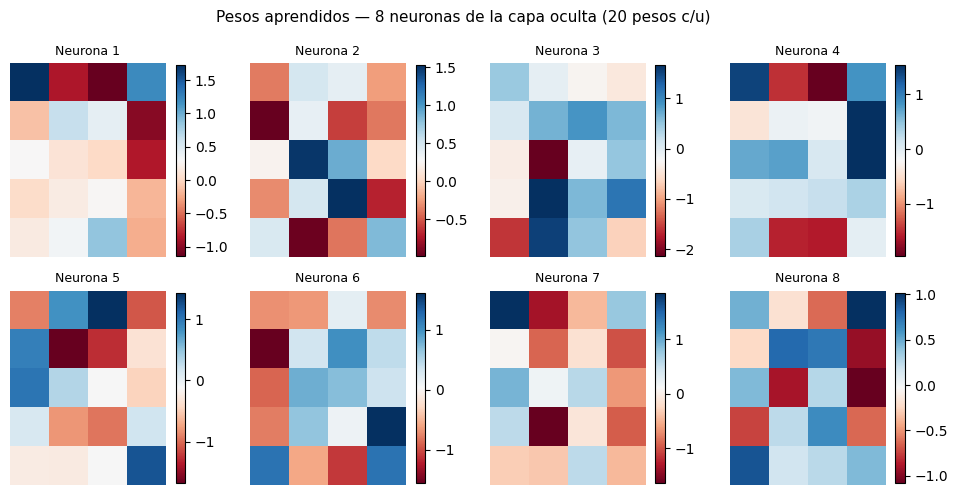

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle("Pesos aprendidos — 8 neuronas de la capa oculta (20 pesos c/u)", fontsize=11)
for k, ax in enumerate(axes.flat):
    pesos = red.W1[:, k].reshape(5, 4)
    im = ax.imshow(pesos, cmap="RdBu", interpolation="nearest")
    ax.set_title(f"Neurona {k+1}", fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("pesos_ocultos.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Conclusión

La red neuronal de una capa oculta (20→8→5) logra clasificar correctamente las cinco vocales tras el entrenamiento con descenso de gradiente. La curva de pérdida muestra una convergencia clara hacia valores cercanos a cero, lo que confirma que la red aprende a asociar cada patrón de píxeles con su clase correspondiente. La prueba con ruido evalúa la capacidad de generalización: la red es robusta ante perturbaciones menores porque los pesos aprendidos capturan la estructura global de cada vocal, no solo los valores exactos de los píxeles. La visualización de los pesos de la capa oculta revela que cada neurona se especializa en detectar rasgos locales distintos de las vocales, lo que ilustra el principio de representaciones distribuidas en redes neuronales.

---

## Referencias

- Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature*, 323, 533–536.
- Nielsen, M. A. (2015). *Neural Networks and Deep Learning*. Determination Press. http://neuralnetworksanddeeplearning.com
- Russell, S. & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.